# 04 · Strategy Monte Carlo - which pit strategy wins, and how often?

We fit a **race model** from real 2023 data (tyre degradation,
pit loss, Safety Car rate), then play thousands of random races for every legal
strategy and compare their race-time distributions.

| Step | Function | Section |
|---|---|---|
| Safety Car rate & length (season) | `estimate_safety_car` | 1 |
| Tyre models, pit loss, noise (one race) | `fit_tyre_models`, `estimate_pit_loss`, `race_params_from_data` | 2 |
| Random races | `draw_safety_car`, `draw_lap_noise` | 3 |
| One strategy -> race-time distribution | `simulate_race_times` | 4 |
| Every strategy, same random races | `enumerate_strategies`, `evaluate_strategies` | 5–6 |


In [1]:
# Run from the repo root so `import src...` works.
import os
import sys
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
sys.path.insert(0, str(Path.cwd()))

import importlib
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import src.models.baselines.race_model as rm
import src.models.baselines.monte_carlo as mc
importlib.reload(rm); importlib.reload(mc)  # re-run this cell after editing the modules
from src.data.ingestion import PROCESSED_DIR, load_laps_parquet
from src.features.season_features import FEATURES_DIR, parse_dataset_path

warnings.filterwarnings("ignore", category=DeprecationWarning)
pd.set_option("display.max_columns", 40, "display.width", 200)
plt.rcParams.update({
    "figure.figsize": (11, 4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.8,
    "axes.edgecolor": "#8a8984", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.titleweight": "bold", "axes.titlesize": 12, "lines.linewidth": 2,
    "legend.frameon": False,
})
COMPOUND_COLORS = {"SOFT": "#e34948", "MEDIUM": "#eda100", "HARD": "#8a8984"}
STOP_COLORS = {1: "#2a78d6", 2: "#eb6834", 3: "#1baf7a"}
INK, MUTED, ACCENT = "#0b0b0b", "#8a8984", "#2a78d6"

In [2]:
features = pd.read_parquet(FEATURES_DIR / "features_R.parquet")
raw = {}
for path in sorted(PROCESSED_DIR.glob("2023_*_R.parquet")):
    year, event, _ = parse_dataset_path(path)
    raw[f"{year}_{event}"] = load_laps_parquet(path)
print(f"{len(raw)} races, {len(features):,} feature rows")

22 races, 20,722 feature rows


## 1 Safety Car: how often, how long? (`estimate_safety_car`)

A single race has 0–4 deployments, far too few for a rate, so we pool the season.

**What to look for**
* Hazard around **0.013 per lap** (≈ one SC every 75 laps) and a duration of about **4 laps**.
* Several races with none at all, a few with 2+: that spread is what the simulator must reproduce (section 3).

In [3]:
SC_HAZARD, SC_DURATION = rm.estimate_safety_car(raw.values())
print(f"season hazard: {SC_HAZARD:.4f} deployments/lap  (one every {1 / SC_HAZARD:.0f} laps)")
print(f"mean duration: {SC_DURATION:.2f} laps")

per_race = pd.DataFrame(
    [(rid, *rm.estimate_safety_car([laps]), int(laps["LapNumber"].max())) for rid, laps in raw.items()],
    columns=["RaceId", "hazard", "duration", "laps"],
)
per_race["deployments"] = (per_race["hazard"] * per_race["laps"]).round().astype(int)
per_race[["RaceId", "laps", "deployments", "duration"]].sort_values("deployments", ascending=False).head(10)

season hazard: 0.0136 deployments/lap  (one every 74 laps)
mean duration: 3.72 laps


,RaceId,laps,deployments,duration
1,2023_australian,58,4,2.25
8,2023_dutch,72,2,5.00
12,2023_las_vegas,50,2,3.50
11,2023_japanese,53,1,4.00
2,2023_austrian,71,1,3.00
3,2023_azerbaijan,51,1,4.00
19,2023_singapore,62,1,4.00
6,2023_british,52,1,7.00
7,2023_canadian,70,1,5.00
18,2023_saudi_arabian,50,1,4.00


## 2 The race model for one race (`race_params_from_data`)

### 2a Tyre models (`fit_tyre_models`)
Dots: every clean lap, **relative to its own driver's median** (the demeaning step).
Lines: the fitted `offset + deg × TyreLife` per compound.

**What to look for**
* Lines go **up** (tyres get slower with age), steeper for softer compounds.
* At TyreLife ≈ 0 the SOFT line should sit **below** the HARD line (softer = faster when new).
  If it doesn't, the fit is picking up something other than the tyres (see section 7).

In [4]:
RACE = "2023_bahrain"
race_features = features[features["RaceId"] == RACE]
params = rm.race_params_from_data(race_features, raw[RACE], sc_hazard_per_lap=SC_HAZARD, sc_duration_laps=SC_DURATION)

print(f"{RACE}: {params.total_laps} laps, base lap {params.base_lap_s:.2f} s, pit loss {params.pit_loss_s:.1f} s, "
      f"noise σ {params.lap_noise_s:.2f} s, SC {params.sc_hazard_per_lap:.4f}/lap × {params.sc_duration_laps} laps")
pd.DataFrame({c: {"offset_s": t.offset_s, "deg_s_per_lap": t.deg_s_per_lap} for c, t in params.tyres.items()}).T.round(3)

2023_bahrain: 57 laps, base lap 96.79 s, pit loss 26.1 s, noise σ 0.46 s, SC 0.0136/lap × 4 laps


,offset_s,deg_s_per_lap
SOFT,-0.834,0.102
HARD,-0.922,0.087


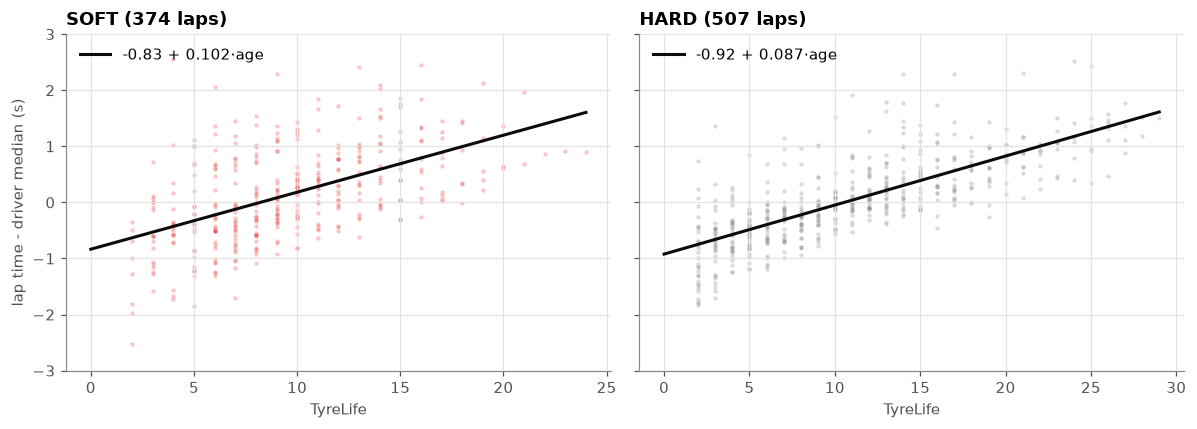

In [15]:
rel = race_features["FuelCorrectedLapTime_s"] - race_features.groupby("Driver", observed=True)[
    "FuelCorrectedLapTime_s"].transform("median")
fig, axes = plt.subplots(1, len(params.tyres), sharey=True, figsize=(11, 4))
for ax, (comp, tyre) in zip(np.atleast_1d(axes), params.tyres.items()):
    rows = race_features["Compound"].astype(str) == comp
    ax.scatter(race_features.loc[rows, "TyreLife"], rel[rows], s=8, alpha=0.3, color=COMPOUND_COLORS[comp], linewidth=0)
    age = np.linspace(0, race_features.loc[rows, "TyreLife"].max(), 50)
    ax.plot(age, tyre.offset_s + tyre.deg_s_per_lap * age, color=INK,
            label=f"{tyre.offset_s:+.2f} + {tyre.deg_s_per_lap:.3f}·age")
    ax.set_title(f"{comp} ({rows.sum()} laps)", loc="left"); ax.set_xlabel("TyreLife"); ax.legend(loc="upper left")
np.atleast_1d(axes)[0].set_ylabel("lap time - driver median (s)")
plt.ylim(-3, 3); plt.tight_layout()

### 2b Pit loss per race (`estimate_pit_loss`)

**What to look for**
* Mostly **18–28 s**. Long pit lanes (Silverstone, Singapore) cost more; short ones less.
* NaN = no green-flag stop in that race (the simulator then uses the 22 s default).

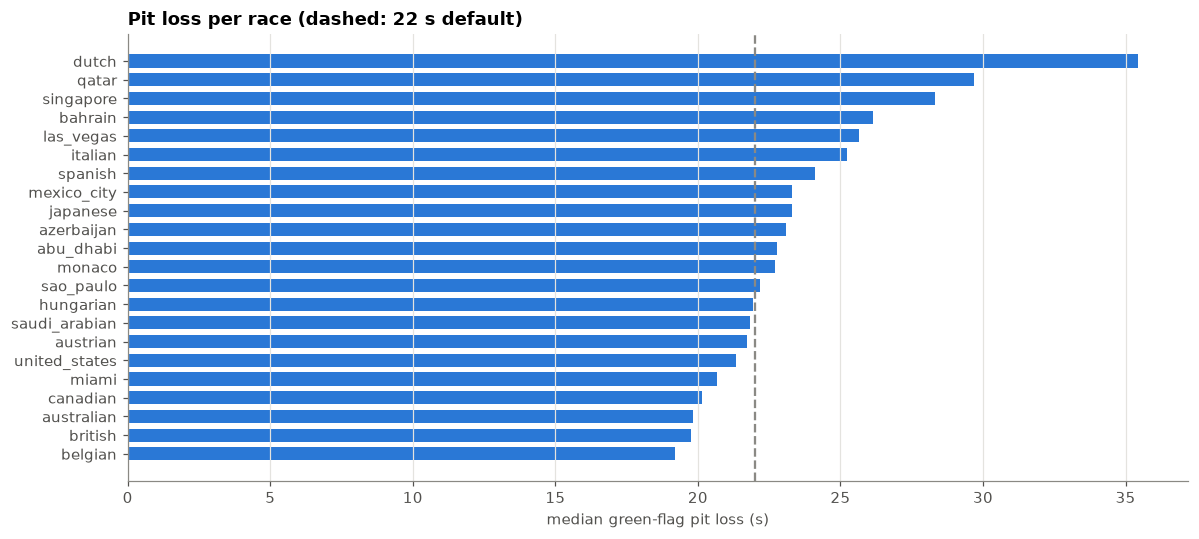

In [6]:
pit_loss = pd.Series({rid: rm.estimate_pit_loss(laps) for rid, laps in raw.items()}).sort_values()
fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(pit_loss.index.str.removeprefix("2023_"), pit_loss.values, color=ACCENT, height=0.7)
ax.axvline(22.0, color=MUTED, linestyle="--", linewidth=1.5)
ax.set_xlabel("median green-flag pit loss (s)"); ax.grid(axis="y", visible=False)
ax.set_title("Pit loss per race (dashed: 22 s default)", loc="left")
plt.tight_layout()

## 3 Random races (`draw_safety_car`, `draw_lap_noise`)

Each row below is one simulated race; dark cells are SC laps.

**What to look for**
* Most races have 0 or 1 SC period, a few have 2+, each ~4 laps long.
* The distribution of deployments per race should look like the real 2023 season.

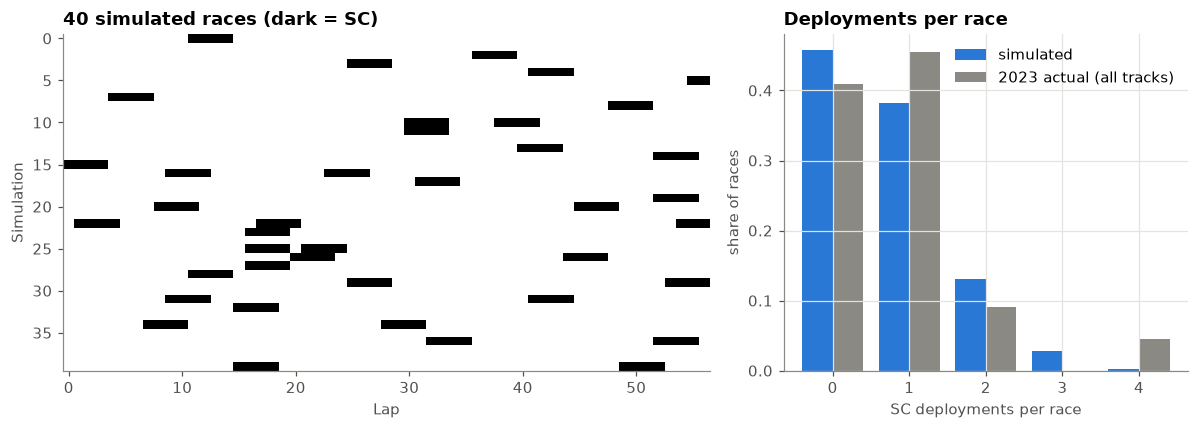

In [7]:
rng = np.random.default_rng(0)
N_SIMS = 4000
sc_mask = mc.draw_safety_car(rng, N_SIMS, params.total_laps, params.sc_hazard_per_lap, params.sc_duration_laps)
noise = mc.draw_lap_noise(rng, N_SIMS, params)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), width_ratios=[1.6, 1])
axes[0].imshow(sc_mask[:40], aspect="auto", cmap="Greys", interpolation="nearest")
axes[0].set_xlabel("Lap"); axes[0].set_ylabel("Simulation"); axes[0].grid(False)
axes[0].set_title("40 simulated races (dark = SC)", loc="left")

starts = (np.diff(np.c_[np.zeros(N_SIMS, bool), sc_mask].astype(int), axis=1) == 1).sum(axis=1)
sim_share = np.bincount(starts, minlength=5)[:5] / N_SIMS
real_share = np.bincount(per_race["deployments"], minlength=5)[:5] / len(per_race)
x = np.arange(5)
axes[1].bar(x - 0.2, sim_share, width=0.4, color=ACCENT, label="simulated")
axes[1].bar(x + 0.2, real_share, width=0.4, color=MUTED, label="2023 actual (all tracks)")
axes[1].set_xticks(x); axes[1].set_xlabel("SC deployments per race"); axes[1].set_ylabel("share of races")
axes[1].legend(); axes[1].set_title("Deployments per race", loc="left")
plt.tight_layout()

## 4 One strategy, thousands of races (`simulate_race_times`)

**What to look for**
* **Separate bumps**, one per number of SC laps: every SC lap adds ~40 % of a lap time
  (≈ 39 s in Bahrain), so 0, 4, 8 … SC laps give clusters ~2.5 min apart.
* The spread is **almost entirely Safety Cars, not lap noise**: compare the two std values printed below.

mean 96.27 min · std 117.6 s · noise-only std 3.4 s


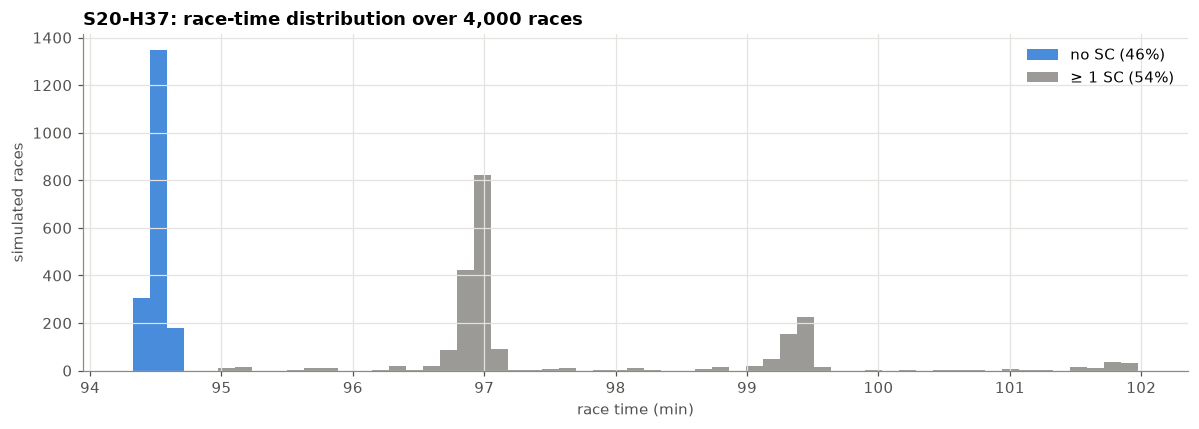

In [8]:
one_stop = mc.Strategy(((params.compounds[0], 20), (params.compounds[-1], params.total_laps - 20)))
times = mc.simulate_race_times(one_stop, params, sc_mask, noise)
had_sc = sc_mask.any(axis=1)

fig, ax = plt.subplots()
bins = np.linspace(times.min(), np.percentile(times, 99.5), 60)
ax.hist(times[~had_sc] / 60, bins=bins / 60, color=ACCENT, alpha=0.85, label=f"no SC ({(~had_sc).mean():.0%})")
ax.hist(times[had_sc] / 60, bins=bins / 60, color=MUTED, alpha=0.85, label=f"≥ 1 SC ({had_sc.mean():.0%})")
ax.set_xlabel("race time (min)"); ax.set_ylabel("simulated races"); ax.legend()
ax.set_title(f"{one_stop.name}: race-time distribution over {N_SIMS:,} races", loc="left")
plt.tight_layout()
print(f"mean {times.mean() / 60:.2f} min · std {times.std():.1f} s · noise-only std {noise.sum(axis=1).std():.1f} s")

### 4a Why common random numbers matter

Compare two strategies **on the same races** vs **on independent races**. The paired
difference is much narrower: SC luck hits both strategies alike and cancels out, so far
fewer simulations are needed to tell strategies apart.

one-stop faster in 20% of the paired races


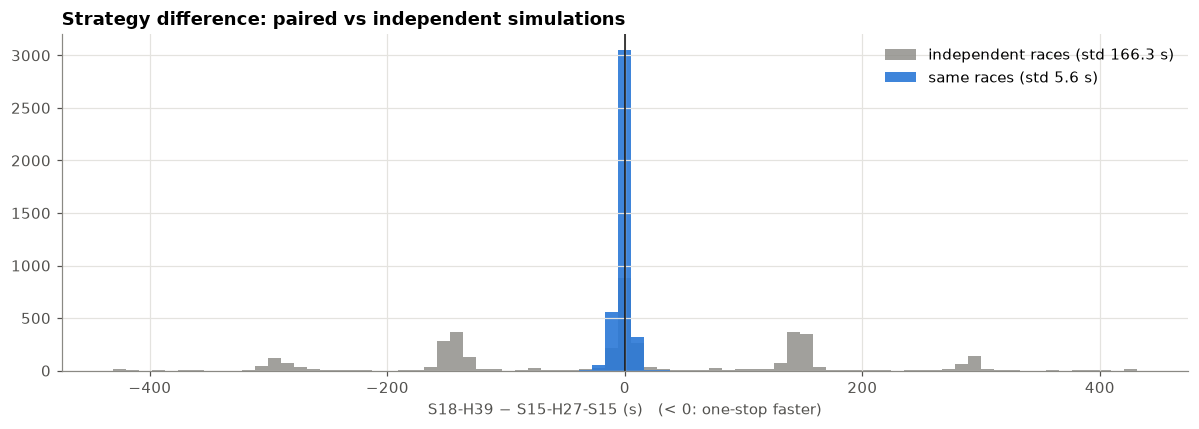

In [9]:
c0, c1 = params.compounds[0], params.compounds[-1]
L = params.total_laps
a = mc.Strategy(((c0, 18), (c1, L - 18)))
b = mc.Strategy(((c0, 15), (c1, L - 30), (c0, 15)))
ta = mc.simulate_race_times(a, params, sc_mask, noise)
tb_same = mc.simulate_race_times(b, params, sc_mask, noise)
rng2 = np.random.default_rng(99)
tb_indep = mc.simulate_race_times(
    b, params,
    mc.draw_safety_car(rng2, N_SIMS, L, params.sc_hazard_per_lap, params.sc_duration_laps),
    mc.draw_lap_noise(rng2, N_SIMS, params),
)
fig, ax = plt.subplots()
lim = np.percentile(np.abs(ta - tb_indep), 98)
bins = np.linspace(-lim, lim, 80)
ax.hist(ta - tb_indep, bins=bins, color=MUTED, alpha=0.8, label=f"independent races (std {np.std(ta - tb_indep):.1f} s)")
ax.hist(ta - tb_same, bins=bins, color=ACCENT, alpha=0.9, label=f"same races (std {np.std(ta - tb_same):.1f} s)")
ax.axvline(0, color=INK, linewidth=1)
ax.set_xlabel(f"{a.name} − {b.name} (s)   (< 0: one-stop faster)"); ax.legend()
ax.set_title("Strategy difference: paired vs independent simulations", loc="left")
plt.tight_layout()
print(f"one-stop faster in {(ta < tb_same).mean():.0%} of the paired races")

## 5 Every legal strategy (`enumerate_strategies` + `evaluate_strategies`)

All 1- and 2-stop strategies with stints ≥ 8 laps, each played on the same 2,000 races.

**What to look for**
* The top is **crowded**: many strategies within a few tenths. Moving a stop by one lap barely matters.
* `win_share` is spread thin for the same reason: near-identical strategies split the wins.
* A clear gap between the best 1-stop and the best 2-stop is the real strategic decision.

In [10]:
strategies = mc.enumerate_strategies(params, max_stops=2, min_stint=8)
t0 = time.perf_counter()
results = mc.evaluate_strategies(strategies, params, n_sims=2000, seed=0)
print(f"{len(strategies):,} strategies × 2,000 races in {time.perf_counter() - t0:.1f} s")
results.head(10).round(3)

3,654 strategies × 2,000 races in 1.5 s


,strategy,n_stops,mean_s,std_s,p05_s,p95_s,delta_to_best_s,win_share
0,H21-H20-S16,2,5770.536,116.778,5662.016,5967.601,0.000,0.000
1,H21-H21-S15,2,5770.583,116.745,5662.138,5967.703,0.047,0.000
2,H20-H21-S16,2,5770.589,116.885,5662.016,5967.898,0.053,0.000
3,H22-H20-S15,2,5770.598,116.650,5662.226,5968.104,0.063,0.000
4,H20-H20-S17,2,5770.604,116.891,5661.996,5967.774,0.068,0.108
5,H22-H19-S16,2,5770.633,116.677,5662.191,5968.071,0.098,0.002
6,H21-H19-S17,2,5770.633,116.780,5662.084,5967.822,0.098,0.000
7,S17-H20-H20,2,5770.667,116.998,5661.996,5967.638,0.131,0.318
8,H19-H21-S17,2,5770.668,116.951,5662.084,5967.850,0.133,0.000
9,S16-H21-H20,2,5770.698,116.965,5662.016,5967.513,0.163,0.000


Best strategy per number of stops:


,strategy,mean_s,std_s,delta_to_best_s
n_stops,,,,
2,H21-H20-S16,5770.54,116.78,0.00
1,H31-S26,5771.17,116.05,0.63


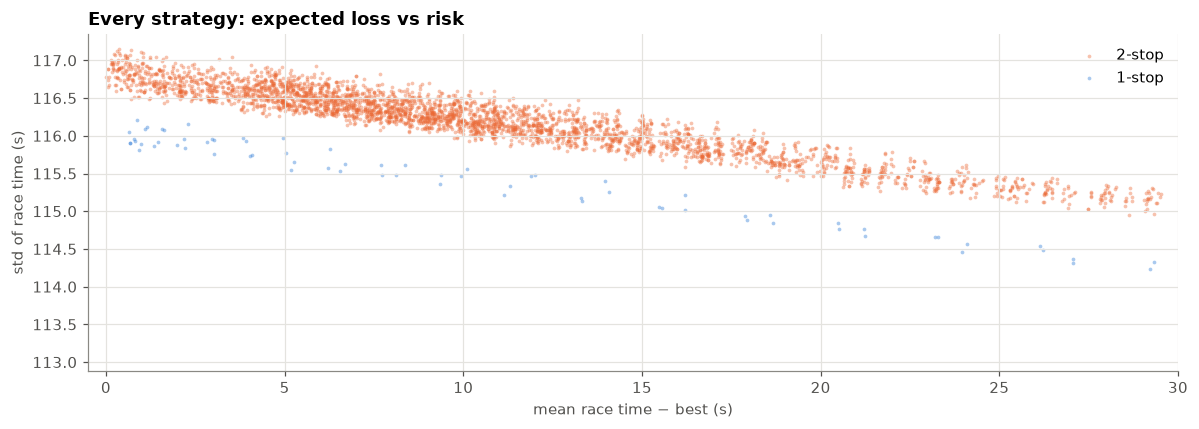

In [11]:
best_per_stops = results.groupby("n_stops").head(1).set_index("n_stops")
print("Best strategy per number of stops:")
display(best_per_stops[["strategy", "mean_s", "std_s", "delta_to_best_s"]].round(2))

fig, ax = plt.subplots()
for n, g in sorted(results.groupby("n_stops"), reverse=True):  # 1-stop drawn on top
    ax.scatter(g["delta_to_best_s"], g["std_s"], s=6, alpha=0.4, color=STOP_COLORS[n], label=f"{n}-stop", linewidth=0)
ax.set_xlim(-0.5, 30); ax.set_xlabel("mean race time − best (s)"); ax.set_ylabel("std of race time (s)")
ax.set_title("Every strategy: expected loss vs risk", loc="left"); ax.legend()
plt.tight_layout()

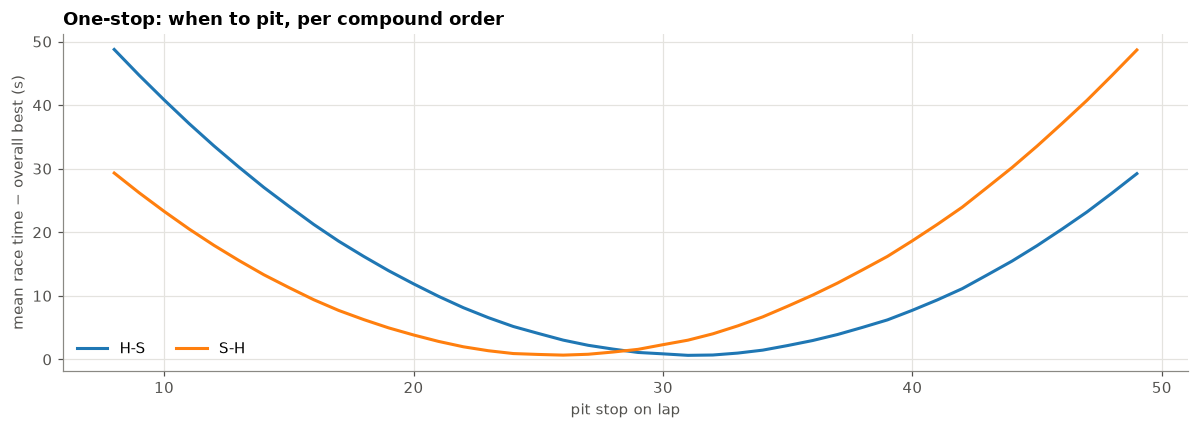

In [12]:
# Best 1-stop: race time vs the lap of the stop, per compound order.
one = results[results["n_stops"] == 1].copy()
one["order"] = one["strategy"].str.replace(r"\d+", "", regex=True)
one["stop_lap"] = one["strategy"].str.extract(r"^[A-Z](\d+)").astype(int)
fig, ax = plt.subplots()
for order, g in one.groupby("order"):
    g = g.sort_values("stop_lap")
    ax.plot(g["stop_lap"], g["delta_to_best_s"], label=order)
ax.set_xlabel("pit stop on lap"); ax.set_ylabel("mean race time − overall best (s)")
ax.set_title("One-stop: when to pit, per compound order", loc="left"); ax.legend(ncol=3)
plt.tight_layout()

## 6 Sensitivity: what if Safety Cars were more / less likely?

A stop under the Safety Car costs half as much. So do more Safety Cars favour more stops?

**What to look for**
* For these **static** strategies the answer is **no**: the 2-stop's edge shrinks and flips as the
  hazard grows. A static plan pits on fixed laps, so it only gets a cheap stop by luck, while SC laps
  cancel the fresh-tyre advantage the extra stop paid for.
* The cheap-stop benefit only exists if you **react** to the Safety Car. That is what reactive
  strategies (4c) and the RL agent (4d) can learn and a fixed plan cannot.

,hazard,best_1stop,best_2stop,2stop_minus_1stop_s
0,0.000,H31-S26,H20-H20-S17,-1.414
1,0.007,S26-H31,H20-S17-H20,-0.969
2,0.014,S26-H31,H20-S17-H20,-0.614
3,0.030,H31-S26,H20-H20-S17,0.297
4,0.050,S26-H31,H20-S17-H20,1.062


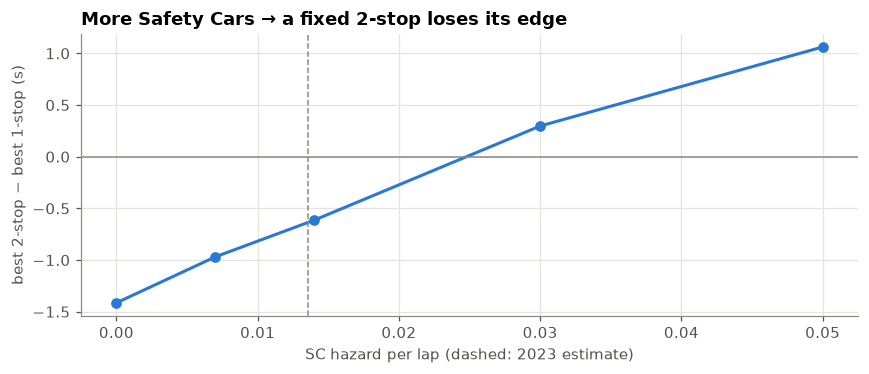

In [13]:
from dataclasses import replace

top = pd.concat([results[results["n_stops"] == n].head(30) for n in (1, 2)])
candidates = [s for s in strategies if s.name in set(top["strategy"])]
rows = []
for hazard in [0.0, 0.0068, SC_HAZARD, 0.03, 0.05]:
    r = mc.evaluate_strategies(candidates, replace(params, sc_hazard_per_lap=hazard), n_sims=2000, seed=1)
    best = r.groupby("n_stops")["mean_s"].min()
    rows.append({"hazard": hazard, "best_1stop": r[r.n_stops == 1].iloc[0]["strategy"],
                 "best_2stop": r[r.n_stops == 2].iloc[0]["strategy"], "2stop_minus_1stop_s": best[2] - best[1]})
sens = pd.DataFrame(rows).round(3)
display(sens)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(sens["hazard"], sens["2stop_minus_1stop_s"], marker="o", color=ACCENT)
ax.axhline(0, color=MUTED, linewidth=1)
ax.axvline(SC_HAZARD, color=MUTED, linestyle="--", linewidth=1)
ax.set_xlabel("SC hazard per lap (dashed: 2023 estimate)"); ax.set_ylabel("best 2-stop − best 1-stop (s)")
ax.set_title("More Safety Cars → a fixed 2-stop loses its edge", loc="left")
plt.tight_layout()

## 7 Whole season: the recommended strategy per race

**What to look for**
* Compare with what teams actually did in 2023 (e.g. Bahrain: most front-runners ran
  SOFT–SOFT–HARD; Monaco: MEDIUM–HARD one-stop).
* Watch for **8-lap stints** (`M8-H50`, `S64-H8`): 8 is `min_stint`, so the optimiser is pushed to the
  boundary. It wants as little of one compound as the rules allow, because the model thinks that
  compound is slow, which is rarely what teams believed.
* Where the recommendation looks odd, check that race's tyre table: a HARD that looks
  **faster** than the SOFT when new usually means the fit is confounded by **track evolution**
  (HARDs are run late, when the track is rubbered-in, cooler, and the fuel effect is not fully
  removed). That is the next model improvement: a shared `LapNumber` term in the regression.

In [14]:
season_rows = []
for rid in raw:
    f = features[features["RaceId"] == rid]
    try:
        p = rm.race_params_from_data(f, raw[rid], sc_hazard_per_lap=SC_HAZARD, sc_duration_laps=SC_DURATION)
    except Exception as exc:  # e.g. fewer than two dry compounds with enough laps
        season_rows.append({"RaceId": rid, "best": f"— ({type(exc).__name__})"})
        continue
    if len(p.compounds) < 2:
        season_rows.append({"RaceId": rid, "best": "— (< 2 compounds with a model)"})
        continue
    r = mc.evaluate_strategies(mc.enumerate_strategies(p, max_stops=2, min_stint=8, step=2), p, n_sims=500)
    soft, hard = p.compounds[0], p.compounds[-1]
    season_rows.append({
        "RaceId": rid, "laps": p.total_laps, "best": r.iloc[0]["strategy"],
        "best_1stop": r[r.n_stops == 1].iloc[0]["strategy"],
        "2stop_gain_s": round(r[r.n_stops == 1]["mean_s"].min() - r[r.n_stops == 2]["mean_s"].min(), 1),
        "pit_loss_s": round(p.pit_loss_s, 1),
        f"softest_new_minus_hardest_new_s": round(p.tyres[soft].offset_s - p.tyres[hard].offset_s, 2),
    })
season_table = pd.DataFrame(season_rows)
season_table

,RaceId,laps,best,best_1stop,2stop_gain_s,pit_loss_s,softest_new_minus_hardest_new_s
0,2023_abu_dhabi,58,M48-H10,M48-H10,-19.6,22.8,0.99
1,2023_australian,58,M8-H50,M8-H50,-21.7,19.8,-0.95
2,2023_austrian,71,M22-M24-H25,M34-H37,14.8,21.7,-0.26
3,2023_azerbaijan,51,M42-H9,M42-H9,-20.4,23.1,-0.25
4,2023_bahrain,57,H22-H20-S15,H32-S25,0.8,26.1,0.09
5,2023_belgian,44,M10-S34,M10-S34,-11.3,19.2,0.72
6,2023_british,52,H8-S44,H8-S44,-24.8,19.8,0.26
7,2023_canadian,70,H16-M54,H16-M54,-15.2,20.1,0.71
8,2023_dutch,72,S64-H8,S64-H8,-79.6,35.4,3.85
9,2023_hungarian,70,H24-H22-M24,M36-H34,6.8,21.9,0.07
